# Standardized DeepHit Baseline (Model Package Import)

## 1. Import Required Libraries

In [ ]:
! pip install duckdb pycox matplotlib --quiet

In [61]:
import importlib
import os
import shutil
import sys

from src.notebook_setup import (
    cleanup_stale_torch,
    compiler_works,
    gcc_major,
    load_module_env,
    module_exists,
    purge_invalid_wheels,
    run,
    try_download_causal_wheel,
    wheelhouse_has,
)

BASE_CACHE = (
    os.environ.get("SCRATCH")
    or os.environ.get("LOCAL_SCRATCH")
    or "/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa"
)
PIP_CACHE_DIR = os.path.join(BASE_CACHE, ".pip-cache")
WHEEL_DIR = os.path.join(BASE_CACHE, ".wheelhouse", "mamba-ssm")
PKG_DIR = os.path.join(BASE_CACHE, ".py-packages")
os.makedirs(PIP_CACHE_DIR, exist_ok=True)
os.makedirs(WHEEL_DIR, exist_ok=True)
os.makedirs(PKG_DIR, exist_ok=True)

# Keep scratch packages available, but after conda site-packages so conda torch is preferred.
if PKG_DIR in sys.path:
    sys.path.remove(PKG_DIR)
sys.path.append(PKG_DIR)

MAMBA_REQ = "mamba-ssm>=2.2.4"

cleanup_stale_torch(PKG_DIR)

if not shutil.which("nvcc"):
    for cuda_module in ["cuda/12.8", "cuda/12.6", "cuda/12.4", "cuda"]:
        if load_module_env(cuda_module) and shutil.which("nvcc"):
            break
nvcc_path = shutil.which("nvcc")
print("CUDA:", nvcc_path if nvcc_path else "not found")

gpp_path = shutil.which("g++")
if not (gpp_path and gcc_major(gpp_path) >= 9 and compiler_works(gpp_path)):
    gpp_path = None

if not gpp_path:
    for gcc_module in [
        "gcc/13.2.1-p20240113",
        "gcc/10.2.0",
        "gcc/13.3.1-p20240614",
        "gcc",
        "gcc/13",
        "gcc/12",
        "gcc/11",
        "gnu/12",
        "gnu/11",
    ]:
        if load_module_env(gcc_module):
            cand = shutil.which("g++")
            if cand and gcc_major(cand) >= 9 and compiler_works(cand):
                gpp_path = cand
                print(f"Selected compiler from module {gcc_module}")
                break

print("g++:", f"{gpp_path} (major {gcc_major(gpp_path)})" if gpp_path else "not usable")

py_ok = (3, 10) <= sys.version_info[:2] <= (3, 12)
if not py_ok:
    print("mamba-ssm installation skipped; Python version unsupported for this build path.")
else:
    run([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel", "ninja"])
    run([sys.executable, "-m", "pip", "install", "--target", PKG_DIR, "numpy"])
    run([sys.executable, "-m", "pip", "install", "--target", PKG_DIR, "einops>=0.7"])
    run([sys.executable, "-m", "pip", "install", "--target", PKG_DIR, "huggingface_hub>=0.23"])
    run([sys.executable, "-m", "pip", "install", "--target", PKG_DIR, "transformers>=4.41,<5"])
    if not module_exists("causal_conv1d"):
        purge_invalid_wheels(WHEEL_DIR, "causal-conv1d")
        try_download_causal_wheel(WHEEL_DIR)
        if wheelhouse_has(WHEEL_DIR, "causal-conv1d"):
            run([
                sys.executable, "-m", "pip", "install",
                "--no-index",
                "--find-links", WHEEL_DIR,
                "--target", PKG_DIR,
                "--no-deps",
                "causal-conv1d",
            ])
        else:
            print("causal-conv1d wheel unavailable; trying forced source build.")
            cenv = os.environ.copy()
            cenv["PYTHONHTTPSVERIFY"] = "0"
            cenv["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"
            cenv["CAUSAL_CONV1D_FORCE_BUILD"] = "TRUE"
            if gpp_path:
                cenv["CXX"] = gpp_path
                cc_guess = gpp_path.replace("g++", "gcc")
                if os.path.exists(cc_guess):
                    cenv["CC"] = cc_guess
            try:
                run([
                    sys.executable, "-m", "pip", "wheel",
                    "--no-build-isolation",
                    "--cache-dir", PIP_CACHE_DIR,
                    "--wheel-dir", WHEEL_DIR,
                    "--trusted-host", "pypi.org",
                    "--trusted-host", "files.pythonhosted.org",
                    "--trusted-host", "github.com",
                    "--trusted-host", "raw.githubusercontent.com",
                    "causal-conv1d>=1.4.0",
                ], env=cenv)
                purge_invalid_wheels(WHEEL_DIR, "causal-conv1d")
                if wheelhouse_has(WHEEL_DIR, "causal-conv1d"):
                    run([
                        sys.executable, "-m", "pip", "install",
                        "--no-index",
                        "--find-links", WHEEL_DIR,
                        "--target", PKG_DIR,
                        "--no-deps",
                        "causal-conv1d",
                    ])
            except Exception as exc:
                print("Forced source build for causal-conv1d failed:", exc)

    binary_ok = False
    try:
        run([
            sys.executable, "-m", "pip", "install",
            "--cache-dir", PIP_CACHE_DIR,
            "--prefer-binary",
            "--only-binary=:all:",
            "--no-deps",
            "--target", PKG_DIR,
            MAMBA_REQ,
        ])
        binary_ok = True
        print("Installed mamba-ssm wheel successfully.")
    except Exception as exc:
        print("mamba-ssm wheel-only install failed; trying source build fallback.")
        print(exc)

    if not binary_ok and not wheelhouse_has(WHEEL_DIR, "mamba-ssm"):
        build_env = os.environ.copy()
        build_env["MAX_JOBS"] = str(max(1, (os.cpu_count() or 4) // 2))
        build_env["MAMBA_FORCE_BUILD"] = "TRUE"
        build_env["PYTHONHTTPSVERIFY"] = "0"
        build_env["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

        if gpp_path:
            build_env["CXX"] = gpp_path
            cc_guess = gpp_path.replace("g++", "gcc")
            if os.path.exists(cc_guess):
                build_env["CC"] = cc_guess

        run([
            sys.executable, "-m", "pip", "wheel",
            "--no-build-isolation",
            "--cache-dir", PIP_CACHE_DIR,
            "--wheel-dir", WHEEL_DIR,
            "--trusted-host", "pypi.org",
            "--trusted-host", "files.pythonhosted.org",
            "--trusted-host", "github.com",
            "--trusted-host", "raw.githubusercontent.com",
            MAMBA_REQ,
        ], env=build_env)

    if wheelhouse_has(WHEEL_DIR, "mamba-ssm") and not module_exists("mamba_ssm"):
        run([
            sys.executable, "-m", "pip", "install",
            "--no-index",
            "--find-links", WHEEL_DIR,
            "--no-deps",
            "--target", PKG_DIR,
            "mamba-ssm",
        ])

cleanup_stale_torch(PKG_DIR)

if module_exists("causal_conv1d") and module_exists("mamba_ssm"):
    causal_conv1d = importlib.import_module("causal_conv1d")
    mamba_ssm = importlib.import_module("mamba_ssm")

    print("Install complete.")
    print("causal_conv1d:", getattr(causal_conv1d, "__version__", "unknown"))
    print("mamba_ssm:", getattr(mamba_ssm, "__version__", "unknown"))
else:
    print("Install not completed in this kernel.")
    if not module_exists("causal_conv1d"):
        print("causal_conv1d is missing.")
    if not module_exists("mamba_ssm"):
        print("mamba_ssm is missing.")
    print("Try a clean module stack before rerunning Cell 4:")
    print("  module purge && module load gcc/13.2.1-p20240113 cuda/12.6")

print("Package dir:", PKG_DIR)
print("PIP cache:", PIP_CACHE_DIR)
print("Wheelhouse:", WHEEL_DIR)
print("Python:", sys.executable)

CUDA: /opt/packages/cuda/v12.6.1/bin/nvcc
g++: /opt/packages/gcc/v13.2.1-p20240113/b2gpu/bin/g++ (major 13)
> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --upgrade pip setuptools wheel ninja
> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --target /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages numpy
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --target /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages einops>=0.7


  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
Using cached einops-0.8.2-py3-none-any.whl (65 kB)


> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --target /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages huggingface_hub>=0.23
  Using cached huggingface_hub-1.10.1-py3-none-any.whl.metadata (14 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached c

  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached numpy-2.4.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached regex-2026.4.4-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached fsspec-202

> /jet/home/ccheung1/.conda/envs/lob/bin/python3.11 -m pip install --cache-dir /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.pip-cache --prefer-binary --only-binary=:all: --no-deps --target /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages mamba-ssm>=2.2.4
mamba-ssm wheel-only install failed; trying source build fallback.
Command '['/jet/home/ccheung1/.conda/envs/lob/bin/python3.11', '-m', 'pip', 'install', '--cache-dir', '/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.pip-cache', '--prefer-binary', '--only-binary=:all:', '--no-deps', '--target', '/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages', 'mamba-ssm>=2.2.4']' returned non-zero exit status 1.
Install complete.
causal_conv1d: 1.6.1
mamba_ssm: 2.3.1
Package dir: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages
PIP cache: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.pip-cache
Wheelhouse: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.wheelhouse/mamba-ssm
Python: /j

ERROR: Could not find a version that satisfies the requirement mamba-ssm>=2.2.4 (from versions: none)
ERROR: No matching distribution found for mamba-ssm>=2.2.4


In [62]:
from __future__ import annotations

import gc
import os
import sys
import warnings
from copy import deepcopy
from pathlib import Path

# Ensure conda torch/site-packages are preferred over scratch target packages.
BASE_CACHE = (
    os.environ.get("SCRATCH")
    or os.environ.get("LOCAL_SCRATCH")
    or "/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa"
)
PKG_DIR = os.path.join(BASE_CACHE, ".py-packages")
if PKG_DIR in sys.path:
    sys.path.remove(PKG_DIR)
sys.path.append(PKG_DIR)

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import torch
except RuntimeError as exc:
    if "already has a docstring" in str(exc):
        raise RuntimeError("PyTorch import state in this kernel is corrupted. Restart the kernel, rerun Cell 4, then rerun Cell 5.") from exc
    raise
from torch.utils.data import DataLoader

from pycox.evaluation import EvalSurv
from pycox.models import DeepHit
from pycox.models.data import pair_rank_mat

from src.models import (
    DeepHitMambaCompeting,
    DeepHitRNNCompeting,
    DeepHitRNNTransformerCompeting,
    DeepHitTransformerCompeting,
)
from src.notebook_data import (
    LabTransform,
    best_day_cut,
    extract_lob_features,
    extract_toxicity_features,
    make_tensors,
)
from src.notebook_evaluation import standard_brier_score, uninformed_brier_score

warnings.filterwarnings("ignore", category=FutureWarning)

print("PyTorch:", torch.__version__)
print("PyTorch loaded from:", Path(torch.__file__).resolve())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cpu":
    cpu_threads = max(1, os.cpu_count() or 1)
    torch.set_num_threads(cpu_threads)
    print(f"CPU threads configured: {cpu_threads}")

PyTorch: 2.10.0+cu128
PyTorch loaded from: /jet/home/ccheung1/.conda/envs/lob/lib/python3.11/site-packages/torch/__init__.py
Device: cuda


## 2. Load and Explore the Dataset

In [63]:
PROJECT_ROOT = Path("/ocean/projects/cis260122p/shared/")

In [64]:
# Verify install status only. Use Cell 4 for installation/retry logic.
import os
import sys

from src.notebook_setup import module_exists

BASE_CACHE = (
    os.environ.get("SCRATCH")
    or os.environ.get("LOCAL_SCRATCH")
    or "/ocean/projects/cis260122p/ccheung1/.cache/lob-dsa"
)
PKG_DIR = os.path.join(BASE_CACHE, ".py-packages")
if PKG_DIR not in sys.path:
    sys.path.insert(0, PKG_DIR)

have_causal = module_exists("causal_conv1d")
have_mamba = module_exists("mamba_ssm")

print("Package dir:", PKG_DIR)
print("Python:", sys.executable)
print("causal_conv1d installed:", have_causal)
print("mamba_ssm installed:", have_mamba)

if not (have_causal and have_mamba):
    print("Run Cell 4 to install mamba dependencies.")
else:
    import causal_conv1d
    import mamba_ssm

    print("causal_conv1d:", getattr(causal_conv1d, "__version__", "unknown"))
    print("mamba_ssm:", getattr(mamba_ssm, "__version__", "unknown"))

Package dir: /ocean/projects/cis260122p/ccheung1/.cache/lob-dsa/.py-packages
Python: /jet/home/ccheung1/.conda/envs/lob/bin/python3.11
causal_conv1d installed: True
mamba_ssm installed: True
causal_conv1d: 1.6.1
mamba_ssm: 2.3.1


In [65]:
DATASET_PATH = PROJECT_ROOT / "data" / "datasets" / "labeled_dataset_XNAS_ITCH_AAPL_mbo_20251001_20260101_equal.parquet"
MAX_TIME = 60.0

query = f"""
SELECT
    entry_time,
    duration_s,
    event_type,
    side,
    entry_representation_raw_top5,
    toxicity_representation
FROM '{DATASET_PATH}'
"""

df_raw = duckdb.query(query).df()
df_raw["entry_representation"] = df_raw["entry_representation_raw_top5"]
del df_raw["entry_representation_raw_top5"]
gc.collect()

print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))

Shape: (62000, 6)
Columns: ['entry_time', 'duration_s', 'event_type', 'side', 'toxicity_representation', 'entry_representation']


### 2a. Recode Event Types: Competing Fill Risks

Late uncensored events re-censored at 60s: 2298
  0: CENSORED             -   2298
  1: FAVORABLE_FILL       -  47733
  2: TOXIC_FILL           -  11969


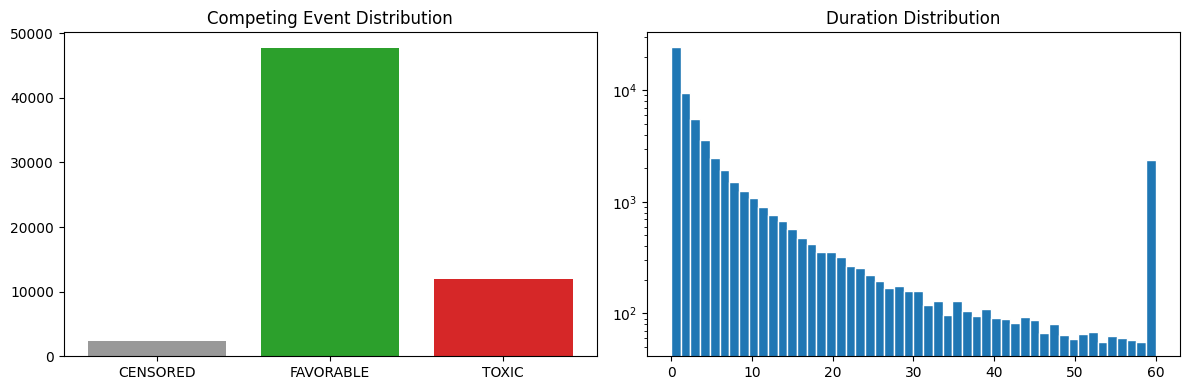

In [66]:
df_raw["event_type_competing"] = df_raw["event_type"].copy()

late_uncensored_mask = df_raw["duration_s"] > MAX_TIME
n_late_uncensored = int(late_uncensored_mask.sum())
if n_late_uncensored > 0:
    df_raw.loc[late_uncensored_mask, "event_type_competing"] = 0
    df_raw.loc[late_uncensored_mask, "duration_s"] = MAX_TIME

label_map = {0: "CENSORED", 1: "FAVORABLE_FILL", 2: "TOXIC_FILL"}
event_counts = df_raw["event_type_competing"].value_counts().sort_index()

print(f"Late uncensored events re-censored at {MAX_TIME:.0f}s: {n_late_uncensored}")
for code in sorted(event_counts.index):
    print(f"  {code}: {label_map.get(int(code), f'UNKNOWN_{code}'):<20} - {event_counts[code]:>6}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(["CENSORED", "FAVORABLE", "TOXIC"], [event_counts.get(0, 0), event_counts.get(1, 0), event_counts.get(2, 0)], color=["#999999", "#2ca02c", "#d62728"])
ax[0].set_title("Competing Event Distribution")
ax[1].hist(df_raw["duration_s"], bins=50, color="#1f77b4", edgecolor="white")
ax[1].set_title("Duration Distribution")
ax[1].set_yscale("log")
plt.tight_layout()
plt.show()

## 3. Preprocess the Dataset
### 3a. Feature Extraction: LOB + Toxicity Dual Streams

In [67]:
LOOKBACK_STEPS = 500
LOB_FEATURE_DIM = 20
TOX_FEATURE_DIM = 12
SEED = 4718

X_lob = extract_lob_features(df_raw, LOOKBACK_STEPS, feat_dim=LOB_FEATURE_DIM)
X_tox = extract_toxicity_features(df_raw, LOOKBACK_STEPS, feat_dim=TOX_FEATURE_DIM)
X_all = np.concatenate([X_lob, X_tox], axis=2)

Y_all = df_raw["duration_s"].values.astype(np.float32)
D_all = df_raw["event_type_competing"].values.astype(np.int64)

print(f"LOB features shape      : {X_lob.shape}")
print(f"Toxicity features shape : {X_tox.shape}")
print(f"Combined features shape : {X_all.shape}")
print(f"Duration vector shape   : {Y_all.shape}")
print(f"Event vector shape      : {D_all.shape}")

LOB features shape      : (62000, 500, 20)
Toxicity features shape : (62000, 500, 14)
Combined features shape : (62000, 500, 34)
Duration vector shape   : (62000,)
Event vector shape      : (62000,)


### 3b. Train / Validation / Test Split
### 3c. Feature Normalisation
### 3d. Discretise Continuous Durations
### 3e. Build PyTorch Datasets

In [68]:
entry_ns = df_raw["entry_time"].values
dates = pd.to_datetime(entry_ns, unit="ns", utc=True).tz_convert("America/New_York").normalize()
unique_days = sorted(dates.unique())
n_days = len(unique_days)
n = len(df_raw)

target_train_end = int(n * 0.70)
target_val_end = int(n * 0.85)
day_end_idx = [(dates <= d).sum() - 1 for d in unique_days]

train_day_idx = best_day_cut(target_train_end, day_end_idx)
val_day_idx = best_day_cut(target_val_end, day_end_idx)
train_day_idx = min(train_day_idx, n_days - 3)
val_day_idx = max(train_day_idx + 1, min(val_day_idx, n_days - 2))

train_end = day_end_idx[train_day_idx] + 1
val_end = day_end_idx[val_day_idx] + 1
idx = np.arange(n)

train_mask = idx < train_end
val_mask = (idx >= train_end) & (idx < val_end)
test_mask = idx >= val_end

X_train, Y_train, D_train = X_all[train_mask], Y_all[train_mask], D_all[train_mask]
X_val, Y_val, D_val = X_all[val_mask], Y_all[val_mask], D_all[val_mask]
X_test, Y_test, D_test = X_all[test_mask], Y_all[test_mask], D_all[test_mask]

feat_mean = X_train.mean(axis=(0, 1), keepdims=True)
feat_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
mask_col_idx = X_train.shape[2] - 1
feat_mean[..., mask_col_idx] = 0.0
feat_std[..., mask_col_idx] = 1.0

X_train_np = ((X_train - feat_mean) / feat_std).astype(np.float16)
X_val_np = ((X_val - feat_mean) / feat_std).astype(np.float16)
X_test_np = ((X_test - feat_mean) / feat_std).astype(np.float16)
X_train_np[..., mask_col_idx] = X_train[..., mask_col_idx]
X_val_np[..., mask_col_idx] = X_val[..., mask_col_idx]
X_test_np[..., mask_col_idx] = X_test[..., mask_col_idx]

NUM_TIME_STEPS = 30
label_transform = LabTransform(NUM_TIME_STEPS, scheme="quantiles")
Y_train_disc, D_train_disc = label_transform.fit_transform(Y_train.copy(), D_train.copy())
Y_val_disc, D_val_disc = label_transform.transform(Y_val.copy(), D_val.copy())
time_grid = label_transform.cuts
output_steps = len(time_grid)

X_train_t, Y_train_t, D_train_t = make_tensors(X_train_np, Y_train_disc, D_train_disc)
X_val_t, Y_val_t, D_val_t = make_tensors(X_val_np, Y_val_disc, D_val_disc)
train_data = list(zip(X_train_t, Y_train_t, D_train_t))
val_data = list(zip(X_val_t, Y_val_t, D_val_t))

print(f"Train samples: {len(train_data):,} | Val samples: {len(val_data):,} | Test samples: {len(X_test_np):,}")
print(f"Output time steps: {output_steps}")

Train samples: 43,000 | Val samples: 10,000 | Test samples: 9,000
Output time steps: 30


## 4. Define the DeepHit Architecture (Imported from src/models)

Set `MODEL_NAME` to one of:
- `gru`
- `gru_transformer`
- `transformer`
- `mamba`

In [71]:
MODEL_NAME = "gru_transformer"
NUM_COMPETING_EVENTS = 2
EVENT_NAMES = ["FAVORABLE_FILL", "TOXIC_FILL"]
EVENT_CODES = [1, 2]

ALPHA = 0.5
SIGMA = 0.1
LEARNING_RATE = 1e-4
BATCH_SIZE = 1024
NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 12

feature_dim = X_train_t.size(2)

if MODEL_NAME == "gru":
    base_net = DeepHitRNNCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=160,
        num_layers=2,
        rnn_dropout=0.2,
        fc_hidden=256 if device.type != "cpu" else 128,
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "gru_transformer":
    base_net = DeepHitRNNTransformerCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=96,
        num_layers=2,
        rnn_dropout=0.2,
        transformer_layers=2,
        transformer_heads=4,
        transformer_ff_dim=192,
        transformer_dropout=0.1,
        max_seq_len=X_train_t.size(1),
        fc_hidden=128 if device.type != "cpu" else 112,
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "transformer":
    base_net = DeepHitTransformerCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=96,
        num_layers=2,
        num_heads=4,
        transformer_ff_dim=320,
        transformer_dropout=0.1,
        max_seq_len=X_train_t.size(1),
        fc_hidden=112,
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "mamba":
    base_net = DeepHitMambaCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=144,
        num_mamba_layers=2,
        d_state=16,
        d_conv=4,
        expand=2,
        mamba_dropout=0.15,
        fc_dropout=0.2,
    ).to(device)
else:
    raise ValueError(f"Unknown MODEL_NAME: {MODEL_NAME}")

deephit_model = DeepHit(
    base_net,
    alpha=ALPHA,
    sigma=SIGMA,
    device=device,
    duration_index=time_grid,
)

total_params = sum(p.numel() for p in base_net.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Input shape: {tuple(X_train_t.shape)}")
print(f"Output shape: ({NUM_COMPETING_EVENTS}, {output_steps})")
print(f"Trainable params: {total_params:,}")

Model: gru_transformer
Input shape: (43000, 500, 34)
Output shape: (2, 30)
Trainable params: 346,716


## 5. Train the DeepHit Model

Epoch   2/100  train=2.3598  val=2.4614  (no improve: 1)
Epoch   4/100  train=2.3286  val=2.3621  (no improve: 0)
Epoch   6/100  train=2.3055  val=2.3507  (no improve: 0)
Epoch   8/100  train=2.2972  val=2.3263  (no improve: 0)
Epoch  10/100  train=2.2841  val=2.3193  (no improve: 0)
Epoch  12/100  train=2.2723  val=2.3012  (no improve: 0)
Epoch  14/100  train=2.2622  val=2.3012  (no improve: 0)
Epoch  16/100  train=2.2567  val=2.3001  (no improve: 1)
Epoch  18/100  train=2.2514  val=2.2837  (no improve: 0)
Epoch  20/100  train=2.2431  val=2.2777  (no improve: 0)
Epoch  22/100  train=2.2376  val=2.2684  (no improve: 0)
Epoch  24/100  train=2.2321  val=2.2618  (no improve: 0)
Epoch  26/100  train=2.2257  val=2.2556  (no improve: 0)
Epoch  28/100  train=2.2227  val=2.2488  (no improve: 0)
Epoch  30/100  train=2.2146  val=2.2452  (no improve: 1)
Epoch  32/100  train=2.2096  val=2.2363  (no improve: 0)
Epoch  34/100  train=2.2043  val=2.2316  (no improve: 0)
Epoch  36/100  train=2.2010  va

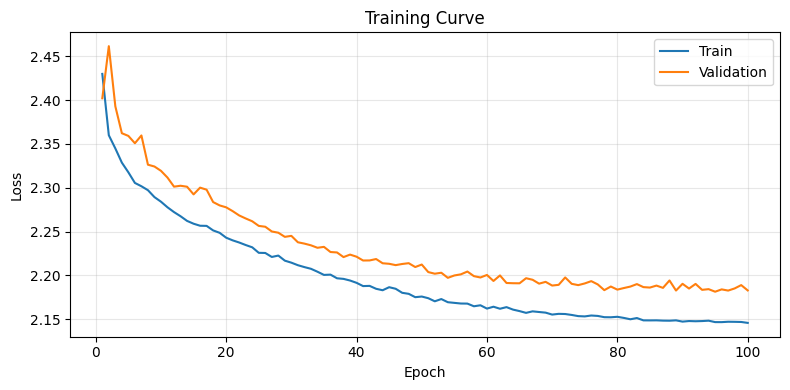

In [72]:
loader_num_workers = 0
loader_pin_memory = device.type != "cpu"

train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=loader_num_workers, pin_memory=loader_pin_memory)
val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=loader_num_workers, pin_memory=loader_pin_memory)

optimizer = torch.optim.Adam(base_net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * 0.1)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_params = None
best_epoch_idx = None
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    base_net.train()
    epoch_loss = 0.0
    n_batches = 0

    for X_b, Y_b, D_b in train_loader:
        X_b = X_b.to(device, non_blocking=loader_pin_memory)
        Y_b = Y_b.to(device, non_blocking=loader_pin_memory)
        D_b = D_b.to(device, non_blocking=loader_pin_memory)

        optimizer.zero_grad()
        surv_logits = base_net(X_b)
        rm = pair_rank_mat(Y_b.detach().cpu().numpy(), D_b.detach().cpu().numpy())
        rm_t = torch.tensor(rm, dtype=torch.int, device=device)
        loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / n_batches

    base_net.eval()
    val_loss_total = 0.0
    n_val_batches = 0
    with torch.no_grad():
        for X_b, Y_b, D_b in val_loader:
            X_b = X_b.to(device, non_blocking=loader_pin_memory)
            Y_b = Y_b.to(device, non_blocking=loader_pin_memory)
            D_b = D_b.to(device, non_blocking=loader_pin_memory)

            surv_logits = base_net(X_b)
            rm = pair_rank_mat(Y_b.detach().cpu().numpy(), D_b.detach().cpu().numpy())
            rm_t = torch.tensor(rm, dtype=torch.int, device=device)
            loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

            val_loss_total += loss.item()
            n_val_batches += 1

    val_loss = val_loss_total / n_val_batches
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch_idx = epoch
        best_params = deepcopy(base_net.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  (no improve: {epochs_no_improve})")

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no val improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

if best_params is not None:
    base_net.load_state_dict(best_params)

print(f"Best val loss {best_val_loss:.4f} at epoch {best_epoch_idx + 1 if best_epoch_idx is not None else -1}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses) + 1), train_losses, label="Train")
ax.plot(range(1, len(val_losses) + 1), val_losses, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Curve")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluate Model Performance
### 6a. Predict Cause-Specific CIFs on the Test Set
### 6b. Cause-Specific Concordance

In [73]:
base_net.eval()
cif_test = deephit_model.predict_cif(
    X_test_np.astype("float32"),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
)

print(f"CIF array shape: {cif_test.shape} (K, T, N)")

ctd_scores = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    one_minus_cif_df = pd.DataFrame(1 - cif_test[k, :, :], index=time_grid)
    ev = EvalSurv(one_minus_cif_df, Y_test, (D_test == event_code).astype(int), censor_surv="km")
    ctd = ev.concordance_td("antolini")
    ctd_scores[event_name] = ctd
    print(f"  {event_name:<20}: C-td = {ctd:.4f}")

macro_ctd = float(np.mean(list(ctd_scores.values())))
n_fav_test = (D_test == 1).sum()
n_tox_test = (D_test == 2).sum()
n_events_test = n_fav_test + n_tox_test
weighted_ctd = (n_fav_test * ctd_scores["FAVORABLE_FILL"] + n_tox_test * ctd_scores["TOXIC_FILL"]) / n_events_test if n_events_test > 0 else 0.0

print(f"Macro-average C-td: {macro_ctd:.4f}")
print(f"Weighted C-td: {weighted_ctd:.4f}")

CIF array shape: (2, 30, 9000) (K, T, N)
  FAVORABLE_FILL      : C-td = 0.6203
  TOXIC_FILL          : C-td = 0.6450
Macro-average C-td: 0.6326
Weighted C-td: 0.6253


### 6c. Distribution of Predicted Cause-Specific Fill Probabilities

Compare final-time CIF predictions for favorable and toxic risks across true outcome groups.

Test set composition:
  CENSORED      : 357
  FAVORABLE_FILL: 6908
  TOXIC_FILL    : 1735

Predicted final CIF means at t=60.0s:
  True FAVORABLE -> CIF(FAVORABLE): 0.7164
  True TOXIC     -> CIF(TOXIC)    : 0.2859


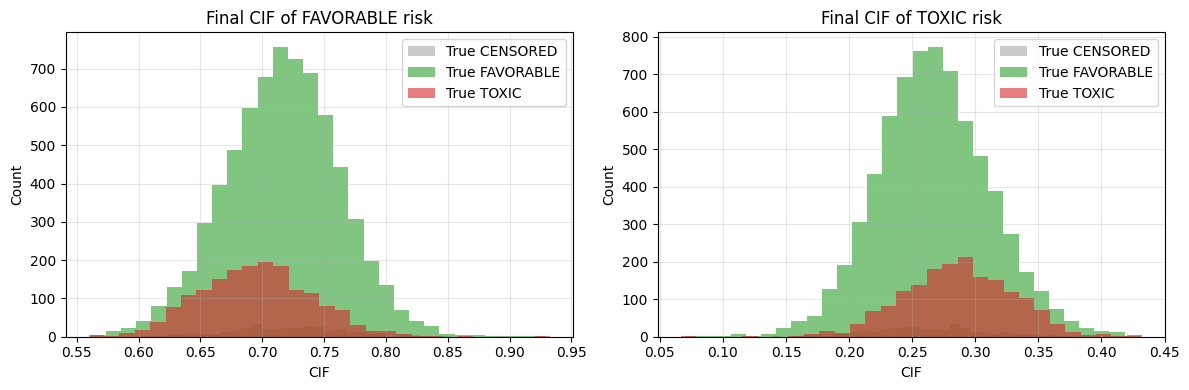

In [74]:
# Final-time cause-specific probabilities
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]

mask_cens = (D_test == 0)
mask_fav = (D_test == 1)
mask_tox = (D_test == 2)

print("Test set composition:")
print(f"  CENSORED      : {int(mask_cens.sum())}")
print(f"  FAVORABLE_FILL: {int(mask_fav.sum())}")
print(f"  TOXIC_FILL    : {int(mask_tox.sum())}")

print(f"\nPredicted final CIF means at t={time_grid[-1]:.1f}s:")
if mask_fav.any():
    print(f"  True FAVORABLE -> CIF(FAVORABLE): {final_cif_fav[mask_fav].mean():.4f}")
if mask_tox.any():
    print(f"  True TOXIC     -> CIF(TOXIC)    : {final_cif_tox[mask_tox].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(final_cif_fav[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[0].hist(final_cif_fav[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[0].hist(final_cif_fav[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[0].set_title("Final CIF of FAVORABLE risk")
axes[0].set_xlabel("CIF")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(final_cif_tox[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[1].hist(final_cif_tox[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[1].hist(final_cif_tox[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[1].set_title("Final CIF of TOXIC risk")
axes[1].set_xlabel("CIF")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6d. Integrated Brier Score

Compute time-dependent standard Brier scores and integrated Brier score (IBS) for each competing event.

Integrated Brier Score (IBS) per event:
  FAVORABLE_FILL      : IBS = 0.1967  |  Uninformed = 0.2193
  TOXIC_FILL          : IBS = 0.1455  |  Uninformed = 0.1445
Macro-average IBS: 0.1711
Macro-average IBS (uninformed): 0.1819
Weighted IBS: 0.1864
Weighted IBS (uninformed): 0.2043


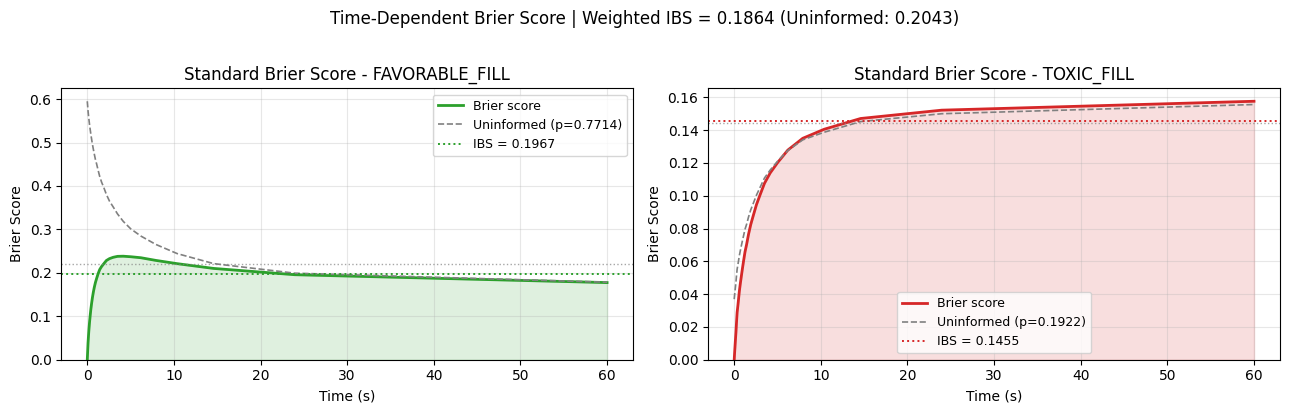

In [75]:
n_train = len(D_train)
p_fav_train = (D_train == 1).sum() / n_train
p_tox_train = (D_train == 2).sum() / n_train

bs_curves = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves[event_name] = standard_brier_score(
        durations=Y_test,
        events=D_test,
        cif_k=cif_test[k],
        event_code=event_code,
        time_grid=time_grid,
    )

bs_curves_uninformed = {
    "FAVORABLE_FILL": uninformed_brier_score(Y_test, D_test, p_fav_train, 1, time_grid),
    "TOXIC_FILL": uninformed_brier_score(Y_test, D_test, p_tox_train, 2, time_grid),
}

t_min, t_max = float(time_grid[0]), float(time_grid[-1])
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

ibs_scores = {}
ibs_scores_uninformed = {}
for event_name, bs_arr in bs_curves.items():
    ibs_scores[event_name] = _trapz(bs_arr, time_grid) / (t_max - t_min)
    ibs_scores_uninformed[event_name] = _trapz(bs_curves_uninformed[event_name], time_grid) / (t_max - t_min)

macro_ibs = float(np.mean(list(ibs_scores.values())))
macro_ibs_uninformed = float(np.mean(list(ibs_scores_uninformed.values())))

n_fav_test = int((D_test == 1).sum())
n_tox_test = int((D_test == 2).sum())
n_events_test = n_fav_test + n_tox_test
weighted_ibs = (
    (n_fav_test * ibs_scores["FAVORABLE_FILL"] + n_tox_test * ibs_scores["TOXIC_FILL"]) / n_events_test
    if n_events_test > 0
    else 0.0
)
weighted_ibs_uninformed = (
    (n_fav_test * ibs_scores_uninformed["FAVORABLE_FILL"] + n_tox_test * ibs_scores_uninformed["TOXIC_FILL"]) / n_events_test
    if n_events_test > 0
    else 0.0
)

print("Integrated Brier Score (IBS) per event:")
for event_name in EVENT_NAMES:
    print(
        f"  {event_name:<20}: IBS = {ibs_scores[event_name]:.4f}  |  Uninformed = {ibs_scores_uninformed[event_name]:.4f}"
    )
print(f"Macro-average IBS: {macro_ibs:.4f}")
print(f"Macro-average IBS (uninformed): {macro_ibs_uninformed:.4f}")
print(f"Weighted IBS: {weighted_ibs:.4f}")
print(f"Weighted IBS (uninformed): {weighted_ibs_uninformed:.4f}")

colors_bs = {"FAVORABLE_FILL": "#2ca02c", "TOXIC_FILL": "#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, event_name in zip(axes, EVENT_NAMES):
    bs_arr = bs_curves[event_name]
    ibs_val = ibs_scores[event_name]
    ibs_uninf_val = ibs_scores_uninformed[event_name]
    color = colors_bs.get(event_name, "#1f77b4")
    baseline_p = p_fav_train if event_name == "FAVORABLE_FILL" else p_tox_train

    ax.plot(time_grid, bs_arr, color=color, linewidth=2, label="Brier score")
    ax.fill_between(time_grid, bs_arr, alpha=0.15, color=color)
    ax.plot(
        time_grid,
        bs_curves_uninformed[event_name],
        color="grey",
        linestyle="--",
        linewidth=1.2,
        label=f"Uninformed (p={baseline_p:.4f})",
    )
    ax.axhline(ibs_uninf_val, color="grey", linestyle=":", linewidth=1, alpha=0.7)
    ax.axhline(ibs_val, color=color, linestyle=":", linewidth=1.4, label=f"IBS = {ibs_val:.4f}")
    ax.set_title(f"Standard Brier Score - {event_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Brier Score")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(
    f"Time-Dependent Brier Score | Weighted IBS = {weighted_ibs:.4f} (Uninformed: {weighted_ibs_uninformed:.4f})",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

### 6e. Visualize Competing CIFs for Sample Orders

Plot favorable-risk CIF, toxic-risk CIF, and implied survival for sample test orders.

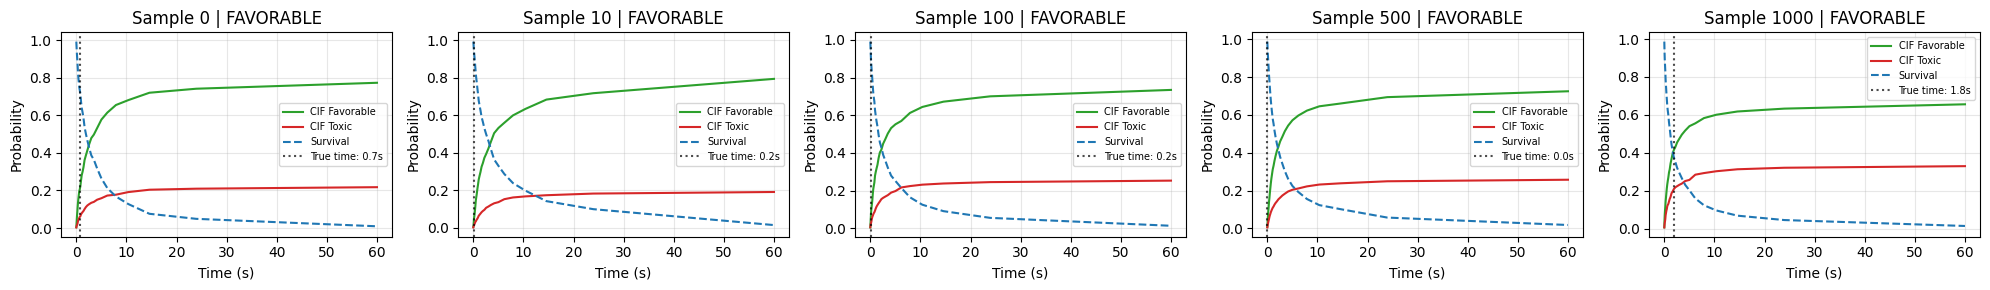

In [76]:
sample_indices = [0, 10, 100, 500, 1000]
sample_indices = [i for i in sample_indices if i < len(X_test_np)]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(4 * max(1, len(sample_indices)), 3))
if len(sample_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_indices):
    cif_fav = cif_test[0, :, idx]
    cif_tox = cif_test[1, :, idx]
    surv_curve = 1.0 - (cif_fav + cif_tox)

    true_time = float(Y_test[idx])
    true_event = int(D_test[idx])
    true_label = "FAVORABLE" if true_event == 1 else ("TOXIC" if true_event == 2 else "CENSORED")

    ax.plot(time_grid, cif_fav, label="CIF Favorable", color="#2ca02c")
    ax.plot(time_grid, cif_tox, label="CIF Toxic", color="#d62728")
    ax.plot(time_grid, surv_curve, label="Survival", color="#1f77b4", linestyle="--")
    ax.axvline(true_time, color="black", linestyle=":", alpha=0.7, label=f"True time: {true_time:.1f}s")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Probability")
    ax.set_title(f"Sample {idx} | {true_label}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6f. PR-AUC and ROC-AUC Evaluation

Primary metric under imbalance: Precision-Recall AUC (Average Precision).

Secondary metric for threshold-invariant ranking context: ROC-AUC.

PR-AUC (Average Precision, OvR):
  Macro AP   : 0.3819
  Weighted AP: 0.6857
  CENSORED            : AP = 0.0537  (random baseline=0.0397)
  FAVORABLE_FILL      : AP = 0.8229  (random baseline=0.7676)
  TOXIC_FILL          : AP = 0.2691  (random baseline=0.1928)


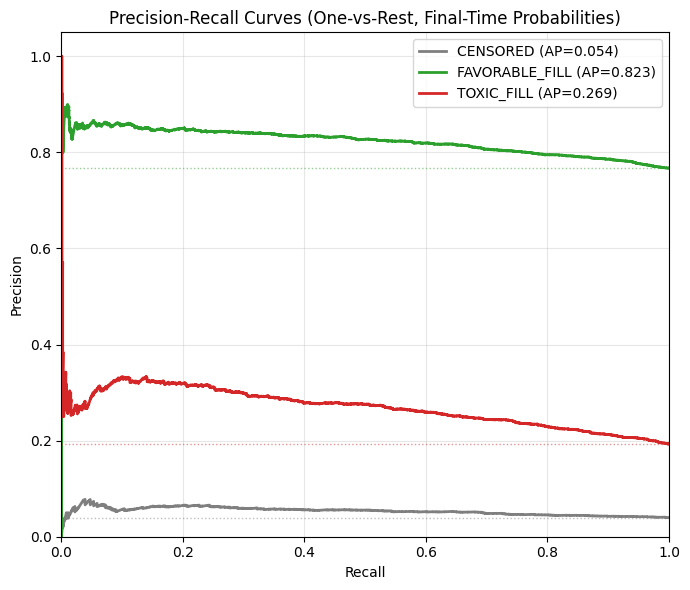


Event-only PR-AUC (FAVORABLE vs TOXIC):
  Samples              : 8643
  AP (toxic as positive): 0.2779
  Random baseline       : 0.2007


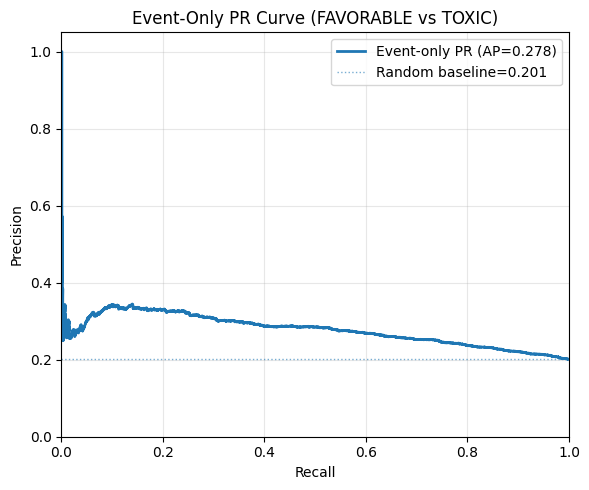


ROC-AUC (OvR):
  Macro AUC   : 0.6104
  Weighted AUC: 0.6107

Censoring diagnostics
Censored samples: 357 / 9000 (4.0%)
Mean survival (censored): 0.0188
Mean survival (events)  : 0.0172
Difference              : +0.0017
Censored with survival > 0.5: 0 / 357 (0.0%)

BASELINE MODEL METRICS SUMMARY
Best_Val_Loss             : 2.1815
Best_Epoch                : 95
Favorable_Ctd             : 0.6203
Toxic_Ctd                 : 0.6450
Weighted_Ctd              : 0.6253
AP_Macro_OvR              : 0.3819
AP_Weighted_OvR           : 0.6857
AP_Event_Only             : 0.2779
AUC_Macro_OvR             : 0.6104
AUC_Weighted_OvR          : 0.6107
Weighted_IBS              : 0.1864
Total_Params              : 346,716


In [77]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

# Scores for classes [0=censored, 1=favorable, 2=toxic]
y_true = D_test.astype(int)
class_labels = [0, 1, 2]
class_names = {0: "CENSORED", 1: "FAVORABLE_FILL", 2: "TOXIC_FILL"}
proba_event = np.vstack([final_surv, final_cif_fav, final_cif_tox]).T
y_true_bin = label_binarize(y_true, classes=class_labels)

# -----------------------------
# Primary: PR-AUC (AP)
# -----------------------------
ap_macro_ovr = average_precision_score(y_true_bin, proba_event, average="macro")
ap_weighted_ovr = average_precision_score(y_true_bin, proba_event, average="weighted")

pr_curves = {}
ap_per_class = {}
prevalence_per_class = {}
for i, cls in enumerate(class_labels):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], proba_event[:, i])
    pr_curves[cls] = (precision, recall)
    ap_per_class[cls] = average_precision_score(y_true_bin[:, i], proba_event[:, i])
    prevalence_per_class[cls] = float((y_true == cls).mean())

print("PR-AUC (Average Precision, OvR):")
print(f"  Macro AP   : {ap_macro_ovr:.4f}")
print(f"  Weighted AP: {ap_weighted_ovr:.4f}")
for cls in class_labels:
    print(
        f"  {class_names[cls]:<20}: AP = {ap_per_class[cls]:.4f}  (random baseline={prevalence_per_class[cls]:.4f})"
    )

fig, ax = plt.subplots(figsize=(7, 6))
colors = {0: "#7f7f7f", 1: "#2ca02c", 2: "#d62728"}
for cls in class_labels:
    precision, recall = pr_curves[cls]
    ax.plot(
        recall,
        precision,
        color=colors[cls],
        lw=2,
        label=f"{class_names[cls]} (AP={ap_per_class[cls]:.3f})",
    )
    ax.hlines(
        prevalence_per_class[cls],
        xmin=0,
        xmax=1,
        colors=colors[cls],
        linestyles=":",
        linewidth=1,
        alpha=0.5,
    )
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves (One-vs-Rest, Final-Time Probabilities)")
ax.grid(alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Event-only PR-AUC: FAVORABLE vs TOXIC (exclude censored)
has_event_mask = (y_true == 1) | (y_true == 2)
n_event_samples = int(has_event_mask.sum())
if n_event_samples > 1 and len(np.unique(y_true[has_event_mask])) == 2:
    y_true_events = y_true[has_event_mask]
    # Positive class is TOXIC_FILL (code 2)
    y_true_events_binary = (y_true_events == 2).astype(int)
    score_toxic = final_cif_tox[has_event_mask]
    precision_ev, recall_ev, _ = precision_recall_curve(y_true_events_binary, score_toxic)
    ap_event_only = average_precision_score(y_true_events_binary, score_toxic)
    toxic_prevalence_events = float(y_true_events_binary.mean())

    print("\nEvent-only PR-AUC (FAVORABLE vs TOXIC):")
    print(f"  Samples              : {n_event_samples}")
    print(f"  AP (toxic as positive): {ap_event_only:.4f}")
    print(f"  Random baseline       : {toxic_prevalence_events:.4f}")

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall_ev, precision_ev, color="#1f77b4", lw=2, label=f"Event-only PR (AP={ap_event_only:.3f})")
    ax.hlines(
        toxic_prevalence_events,
        xmin=0,
        xmax=1,
        colors="#1f77b4",
        linestyles=":",
        linewidth=1,
        alpha=0.6,
        label=f"Random baseline={toxic_prevalence_events:.3f}",
    )
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Event-Only PR Curve (FAVORABLE vs TOXIC)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    ap_event_only = float("nan")
    print("\nEvent-only PR-AUC skipped (insufficient non-censored class variety).")

# -----------------------------
# Secondary: ROC-AUC
# -----------------------------
auc_macro_ovr = roc_auc_score(y_true_bin, proba_event, average="macro", multi_class="ovr")
auc_weighted_ovr = roc_auc_score(y_true_bin, proba_event, average="weighted", multi_class="ovr")

print("\nROC-AUC (OvR):")
print(f"  Macro AUC   : {auc_macro_ovr:.4f}")
print(f"  Weighted AUC: {auc_weighted_ovr:.4f}")

# Keep censoring diagnostics
is_censored = y_true == 0
n_censored = int(is_censored.sum())
surv_prob_censored = final_surv[is_censored]
surv_prob_events = final_surv[has_event_mask] if has_event_mask.any() else np.array([0.0])

avg_surv_censored = float(surv_prob_censored.mean()) if n_censored > 0 else 0.0
avg_surv_events = float(surv_prob_events.mean())
threshold = 0.5
correct_cens = int((surv_prob_censored > threshold).sum()) if n_censored > 0 else 0

print("\nCensoring diagnostics")
print(f"Censored samples: {n_censored} / {len(y_true)} ({100 * is_censored.mean():.1f}%)")
print(f"Mean survival (censored): {avg_surv_censored:.4f}")
print(f"Mean survival (events)  : {avg_surv_events:.4f}")
print(f"Difference              : {avg_surv_censored - avg_surv_events:+.4f}")
if n_censored > 0:
    print(f"Censored with survival > {threshold}: {correct_cens} / {n_censored} ({100 * correct_cens / n_censored:.1f}%)")

metrics_summary = {
    "Best_Val_Loss": f"{best_val_loss:.4f}" if best_val_loss is not None else "N/A",
    "Best_Epoch": best_epoch_idx + 1 if best_epoch_idx is not None else "N/A",
    "Favorable_Ctd": f"{ctd_scores.get('FAVORABLE_FILL', 0):.4f}",
    "Toxic_Ctd": f"{ctd_scores.get('TOXIC_FILL', 0):.4f}",
    "Weighted_Ctd": f"{weighted_ctd:.4f}",
    "AP_Macro_OvR": f"{ap_macro_ovr:.4f}",
    "AP_Weighted_OvR": f"{ap_weighted_ovr:.4f}",
    "AP_Event_Only": f"{ap_event_only:.4f}" if np.isfinite(ap_event_only) else "N/A",
    "AUC_Macro_OvR": f"{auc_macro_ovr:.4f}",
    "AUC_Weighted_OvR": f"{auc_weighted_ovr:.4f}",
    "Weighted_IBS": f"{weighted_ibs:.4f}" if "weighted_ibs" in globals() else "N/A",
    "Total_Params": f"{total_params:,}",
}

print("\n" + "=" * 70)
print("BASELINE MODEL METRICS SUMMARY")
print("=" * 70)
for key, value in metrics_summary.items():
    print(f"{key:<25} : {value}")
print("=" * 70)

mamba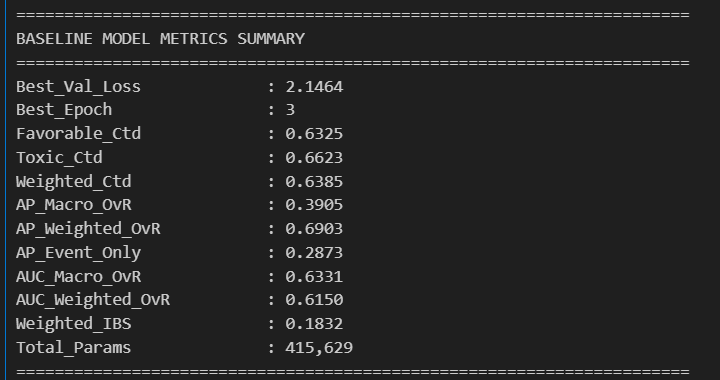

gru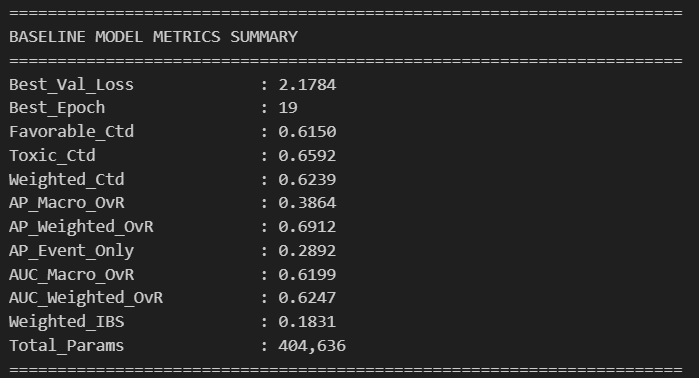

transformer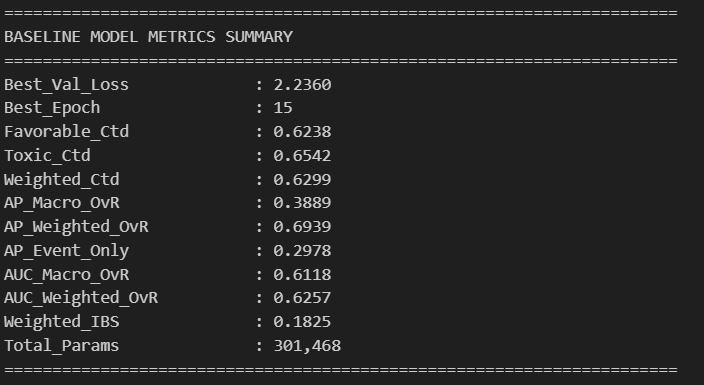

gru_transformer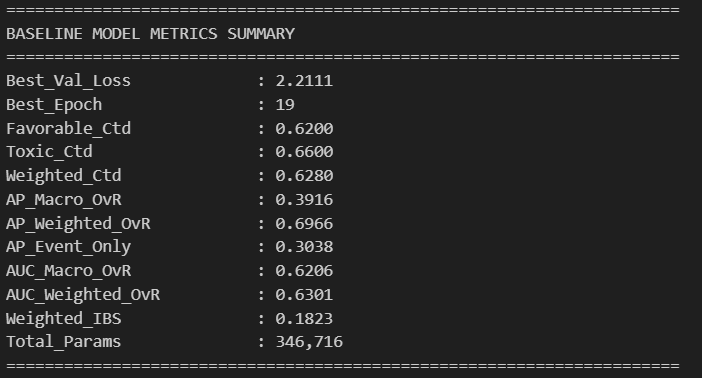

mamba small lr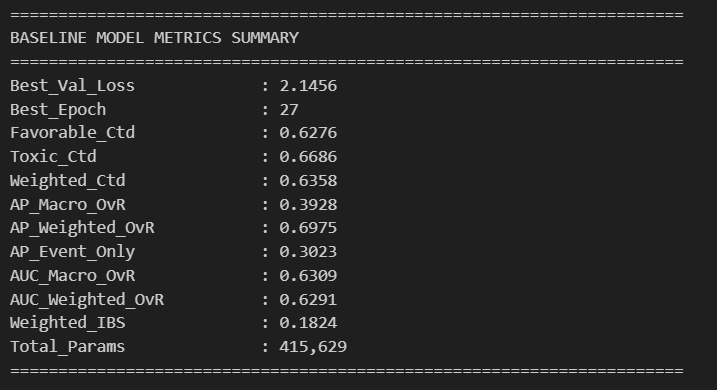

gru_transformer small lr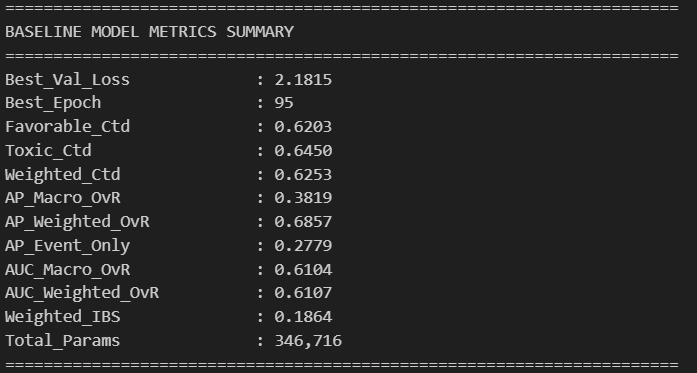

## 7. Save Model Artifacts

In [78]:
artifact_dir = PROJECT_ROOT / "artifacts" / "baseline"
artifact_dir.mkdir(parents=True, exist_ok=True)

model_save_path = artifact_dir / f"standardized_deephit_{MODEL_NAME}_base_net.pt"
meta_save_path = artifact_dir / f"standardized_deephit_{MODEL_NAME}_meta.pt"

torch.save(base_net.state_dict(), model_save_path)
metadata = {
    "model_name": MODEL_NAME,
    "num_competing_events": NUM_COMPETING_EVENTS,
    "event_names": EVENT_NAMES,
    "output_steps": output_steps,
    "time_grid": time_grid,
    "lookback_steps": LOOKBACK_STEPS,
    "learning_rate": LEARNING_RATE,
    "best_epoch": best_epoch_idx + 1 if best_epoch_idx is not None else None,
    "best_val_loss": best_val_loss,
}
torch.save(metadata, meta_save_path)

print(f"Model saved to: {model_save_path.relative_to(PROJECT_ROOT)}")
print(f"Metadata saved to: {meta_save_path.relative_to(PROJECT_ROOT)}")

Model saved to: artifacts/baseline/standardized_deephit_gru_transformer_base_net.pt
Metadata saved to: artifacts/baseline/standardized_deephit_gru_transformer_meta.pt
